In [1]:
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import modin.pandas as pd
import plotly.graph_objects as go
from collections import Counter

In [3]:
jobs_data_dir = "C:\\Users\\eshad\\OneDrive\\Desktop\\TU Delft\\Thesis\\Data Scraping\\Data\\7. Deduplicated data"
folder_names = ["Batch 1", "Batch 2"]
dataframes = []
# Read all files in the directory
for folder_name in folder_names:
    for file_name in os.listdir(os.path.join(jobs_data_dir, folder_name)):
        if '2024' in file_name:
            print(file_name)
            file_path = os.path.join(jobs_data_dir, folder_name, file_name)
            tmp_df = pd.read_csv(file_path, usecols = ['jobPostingId', 'Industry', 'country', 'role'])
            tmp_df = tmp_df.dropna(how='any')
            dataframes.append(tmp_df)
job_postings_df = pd.concat(dataframes)
print(len(job_postings_df))
job_postings_df.head()

annotated_data_2024_removed_words.csv


2025-05-08 11:14:15,469	INFO worker.py:1841 -- Started a local Ray instance.
Data types of partitions are different! Please refer to the troubleshooting section of the Modin documentation to fix this issue.


annotated_data_2024_batch_2_removed_words.csv
76274


,jobPostingId,country,Industry,role
0,3824426275,United States of America,retail,Front-End Developer
1,3824425537,United States of America,it services and it consulting,DevOps Specialist
2,3824425417,United States of America,retail,Front-End Developer
3,3824425039,United States of America,software development,Data or Business Analyst
4,3824424451,United States of America,retail,Front-End Developer


In [42]:
recommendations_df = pd.read_csv('Recommendation Data/tf_idf_16000.csv')
print(len(recommendations_df))
recommendations_df.head()

160000


,Unnamed: 0,cv_index,CV,applicant_gender,jobPostingId,title,description,gender_category,rank
0,0,0,```plaintext\n**Summary** \nDynamic and detai...,female,3822726679,Dotnet Developer,**Job Title: Junior/Mid Software Developer (as...,fem,1
1,1,0,```plaintext\n**Summary** \nDynamic and detai...,female,3850910575,ASP.NET Developer,The ASP.NET Developer is responsible for the d...,fem,2
2,2,0,```plaintext\n**Summary** \nDynamic and detai...,female,3879707553,Node.js Developer,We are seeking an experienced Senior Node.js D...,fem,3
3,3,0,```plaintext\n**Summary** \nDynamic and detai...,female,3966594528,Full Stack Engineer-NET,How you should be?\nWe are looking for a talen...,fem,4
4,4,0,```plaintext\n**Summary** \nDynamic and detai...,female,4090470487,.NET Software Engineer with React,"Skills:\nC#, ASP.NET, React, JavaScript, SQL, ...",neutral,5


In [43]:
industry_mapping = {
    "Technology and IT": [
        'software development', 'it services and it consulting',
        'computer and network security', 'technology, information and internet',
        'technology, information and media', 'computer games', 'computer networking products',
        'mobile gaming apps', 'internet publishing', 'internet marketplace platforms',
        'desktop computing software products', 'mobile computing software products',
        'data infrastructure and analytics', 'data security software products',
        'it system custom software development', 'it system data services',
        'it system training and support', 'blockchain services', 'wireless services',
        'business intelligence platforms', 'telecommunications', 'information services'
    ],
    "Healthcare and Life Sciences": [
        'hospitals', 'hospitals and health care', 'pharmaceutical manufacturing',
        'biotechnology research', 'mental health care', 'medical practices',
        'medical and diagnostic laboratories', 'home health care services',
        'veterinary services', 'alternative medicine', 'health and human services',
        'physicians', 'public health'
    ],
    "Manufacturing": [
        'defense and space manufacturing', 'oil and gas',
        'semiconductor manufacturing', 'industrial machinery manufacturing',
        'medical equipment manufacturing', 'machinery manufacturing', 'motor vehicle parts manufacturing',
        'computers and electronics manufacturing', 'textile manufacturing',
        'computer hardware manufacturing', 'renewable energy semiconductor manufacturing',
        'appliances, electrical, and electronics manufacturing', 'sporting goods manufacturing',
        'chemical manufacturing', 'motor vehicle manufacturing',
        'automation machinery manufacturing', 'food and beverage manufacturing',
        'beverage manufacturing', 'tobacco manufacturing', 'dairy product manufacturing',
        'packaging and containers manufacturing', 'furniture and home furnishings manufacturing',
        'glass, ceramics and concrete manufacturing', 'manufacturing',
        'paper and forest product manufacturing', 'plastics manufacturing',
        'climate technology product manufacturing', 'measuring and control instrument manufacturing'
    ],
    "Education and Research": [
        'higher education', 'research services', 'e-learning providers',
        'education administration programs', 'education', 'primary and secondary education',
        'libraries', 'think tanks', 'nanotechnology research'
    ],
    "Finance and Professional Services": [
        'financial services', 'insurance', 'accounting', 'market research',
        'capital markets', 'investment banking', 'investment management',
        'venture capital and private equity principals', 'business consulting and services',
        'human resources services', 'professional services',
        'strategic management services', 'executive search services',
        'operations consulting', 'banking'
    ],
    "Media and Entertainment": [
        'advertising services', 'public relations and communications services',
        'entertainment providers', 'broadcast media production and distribution',
        'media production', 'online audio and video media', 'musicians',
        'movies, videos, and sound', 'animation and post-production',
        'book and periodical publishing', 'newspaper publishing',
        'internet news', 'blogs', 'performing arts', 'artists and writers',
        'writing and editing', 'photography', 'business content'
    ],
    "Retail and Consumer Services": [
        'retail', 'retail luxury goods and jewelry', 'retail apparel and fashion',
        'retail groceries', 'retail office equipment', 'retail art supplies',
        'consumer services', 'restaurants', 'food and beverage services',
        'food and beverage retail', 'personal care product manufacturing'
    ],
    "Engineering and Construction": [
        'civil engineering', 'engineering services', 'construction',
        'architecture and planning', 'building construction', 'robotics engineering'
    ],
    "Transportation and Logistics": [
        'aviation and aerospace component manufacturing', 'airlines and aviation',
        'truck transportation', 'maritime transportation',
        'rail transportation', 'railroad equipment manufacturing',
        'urban transit services', 'freight and package transportation',
        'transportation, logistics, supply chain and storage',
        'ground passenger transportation', 'vehicle repair and maintenance',
        'transportation equipment manufacturing'
    ],
    "Energy and Environment": [
        'utilities', 'renewable energy power generation',
        'solar electric power generation', 'electric power generation',
        'renewable energy equipment manufacturing',
        'services for renewable energy', 'environmental services',
        'climate data and analytics'
    ],
    "Nonprofit, Government, and Policy": [
        'non-profit organizations', 'civic and social organizations',
        'government administration', 'international affairs', 'public safety',
        'public policy offices', 'government relations services',
        'political organizations', 'philanthropic fundraising services',
        'religious institutions', 'fundraising', 'armed forces',
        'legislative offices', 'law enforcement', 'administration of justice'
    ],
    "Law and Legal Services": [
        'law practice', 'legal services', 'alternative dispute resolution'
    ],
    "Arts and Design": [
        'graphic design', 'interior design'
    ],
    "Hospitality and Leisure": [
        'hospitality', 'travel arrangements', 'gambling facilities and casinos',
        'recreational facilities', 'events services', 'museums',
        'museums, historical sites, and zoos', 'spectator sports', 'wellness and fitness services'
    ],
    "Agriculture and Natural Resources": [
        'farming', 'horticulture', 'fisheries', 'mining'
    ],
    "Real Estate and Property": [
        'real estate', 'leasing non-residential real estate',
        'wholesale building materials'
    ],
    "Wholesale and Trade": [
        'wholesale', 'wholesale import and export'
    ],
    "Staffing and Human Capital": [
        'staffing and recruiting', 'executive offices'
    ],
    "Miscellaneous": [
        'printing services', 'design services', 'animation and post-production', 'professional training and coaching',
        'outsourcing and offshoring consulting', 'social networking platforms', 'individual and family services',
        'desktop computing software products', 'fire protection',  'warehousing and storage',
        'home health care services', 'taxi and limousine services', 'pet services', 'shipbuilding',
        'digital accessibility services', 'security and investigations', 'international trade and development',
        'holding companies', 'equipment', 'translation and localization', 'facilities services'
    ]
}


# Reverse mapping: role -> grouped_role
flat_mapping = {role: group for group, roles in industry_mapping.items() for role in roles}
flat_mapping

{'software development': 'Technology and IT',
 'it services and it consulting': 'Technology and IT',
 'computer and network security': 'Technology and IT',
 'technology, information and internet': 'Technology and IT',
 'technology, information and media': 'Technology and IT',
 'computer games': 'Technology and IT',
 'computer networking products': 'Technology and IT',
 'mobile gaming apps': 'Technology and IT',
 'internet publishing': 'Technology and IT',
 'internet marketplace platforms': 'Technology and IT',
 'desktop computing software products': 'Miscellaneous',
 'mobile computing software products': 'Technology and IT',
 'data infrastructure and analytics': 'Technology and IT',
 'data security software products': 'Technology and IT',
 'it system custom software development': 'Technology and IT',
 'it system data services': 'Technology and IT',
 'it system training and support': 'Technology and IT',
 'blockchain services': 'Technology and IT',
 'wireless services': 'Technology and 

In [44]:
# Apply mapping
job_postings_df['grouped_industry'] = job_postings_df['Industry'].map(flat_mapping).fillna(job_postings_df['Industry'])
job_postings_df.head()

,jobPostingId,country,Industry,role,grouped_industry
0,3824426275,United States of America,retail,Front-End Developer,Retail and Consumer Services
1,3824425537,United States of America,it services and it consulting,DevOps Specialist,Technology and IT
2,3824425417,United States of America,retail,Front-End Developer,Retail and Consumer Services
3,3824425039,United States of America,software development,Data or Business Analyst,Technology and IT
4,3824424451,United States of America,retail,Front-End Developer,Retail and Consumer Services


In [45]:
recommendations_df = recommendations_df.merge(job_postings_df, how='left', on='jobPostingId', suffixes=('_x', '_y'))
recommendations_df.head()

,Unnamed: 0,cv_index,CV,applicant_gender,jobPostingId,title,description,gender_category,rank,country,Industry,role,grouped_industry
0,0,0,```plaintext\n**Summary** \nDynamic and detai...,female,3822726679,Dotnet Developer,**Job Title: Junior/Mid Software Developer (as...,fem,1,Nepal,software development,.Net Developer,Technology and IT
1,1,0,```plaintext\n**Summary** \nDynamic and detai...,female,3850910575,ASP.NET Developer,The ASP.NET Developer is responsible for the d...,fem,2,Saudi Arabia,accounting,.Net Developer,Finance and Professional Services
2,2,0,```plaintext\n**Summary** \nDynamic and detai...,female,3879707553,Node.js Developer,We are seeking an experienced Senior Node.js D...,fem,3,India,it services and it consulting,JavaScript Developer,Technology and IT
3,3,0,```plaintext\n**Summary** \nDynamic and detai...,female,3966594528,Full Stack Engineer-NET,How you should be?\nWe are looking for a talen...,fem,4,India,it services and it consulting,Full-Stack Developer,Technology and IT
4,4,0,```plaintext\n**Summary** \nDynamic and detai...,female,4090470487,.NET Software Engineer with React,"Skills:\nC#, ASP.NET, React, JavaScript, SQL, ...",neutral,5,India,it services and it consulting,.Net Developer,Technology and IT


## Applicant Gender vs Job Ad Gender Category

In [101]:
# Prepare data
gender_counts = recommendations_df.groupby(['applicant_gender', 'gender_category']).size().reset_index(name='count')
gender_counts['count'] = gender_counts['count'].astype(int)

# Pivot to make a stacked format
gender_pivot = gender_counts.pivot(index='gender_category', columns='applicant_gender', values='count').fillna(0)

# Calculate total per gender_category
totals = gender_pivot.sum(axis=1)
percentages = gender_pivot.div(totals, axis=0) * 100  # for percentages

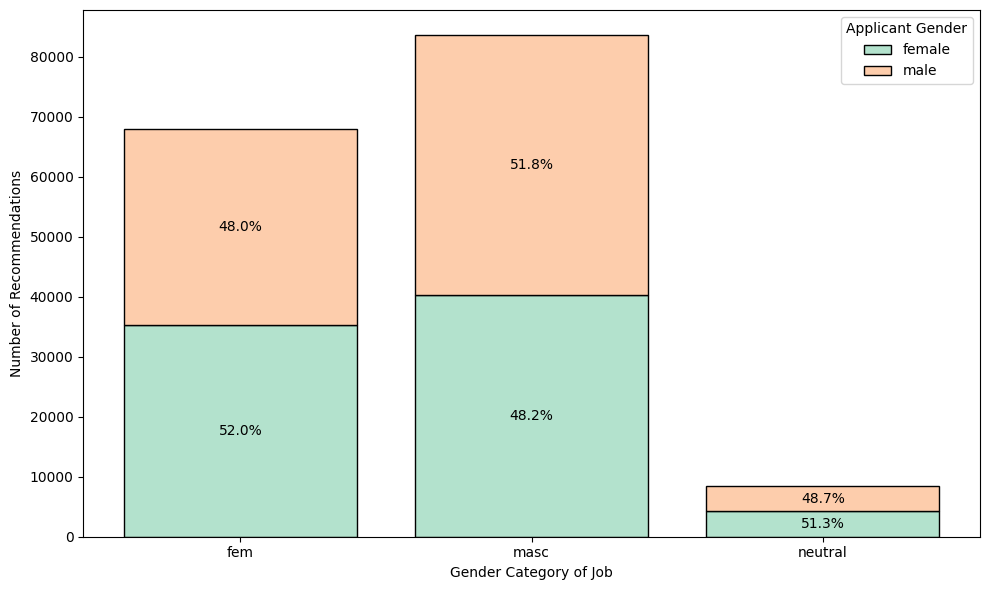

In [102]:
# Plot
fig, ax = plt.subplots(figsize=(10, 6))

bottom = np.zeros(len(gender_pivot))  # start at bottom = 0 for stacking
colors = plt.cm.Pastel2.colors  # pastel color palette
# colors = ['#000000', '#D3D3D3']
for i, applicant_gender in enumerate(gender_pivot.columns):
    values = gender_pivot[applicant_gender]
    ax.bar(gender_pivot.index, values, bottom=bottom, label=applicant_gender, color=colors[i % len(colors)], edgecolor='black')
    
    # Add percentage text inside each bar
    for j, (value, percent) in enumerate(zip(values, percentages[applicant_gender])):
        if value > 0:
            ax.text(
                j,                   # x-position (index of gender_category)
                bottom[j] + value/2,  # y-position (middle of current stack)
                f"{percent:.1f}%",
                ha='center',
                va='center',
                fontsize=10,
                color='black'
            )
    
    bottom += values  # update bottom for stacking

# Final plot formatting
# ax.set_title('Distribution of Recommended Gender Categories by Applicant Gender')
ax.set_ylabel('Number of Recommendations')
ax.set_xlabel('Gender Category of Job')
ax.legend(title='Applicant Gender')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('job_gender_word2vec_skipgrams_bigrams')
plt.show()

## Applicant Gender vs Industry 

In [46]:
# Prepare data
industry_gender = recommendations_df.groupby(['grouped_industry', 'applicant_gender']).size().unstack(fill_value=0)

# Keep only top 20 industries by total jobs
top_industries = industry_gender.sum(axis=1).sort_values(ascending=False).head(10).index
industry_gender_top = industry_gender.loc[top_industries]

# Add total counts to industry labels
industry_totals = industry_gender_top.sum(axis=1)
industry_gender_top.index = [f"{industry} ({total})" for industry, total in zip(industry_gender_top.index, industry_totals)]

In [47]:
# Compute percentages separately
industry_gender_percent = industry_gender_top.div(industry_totals.values, axis=0) * 100

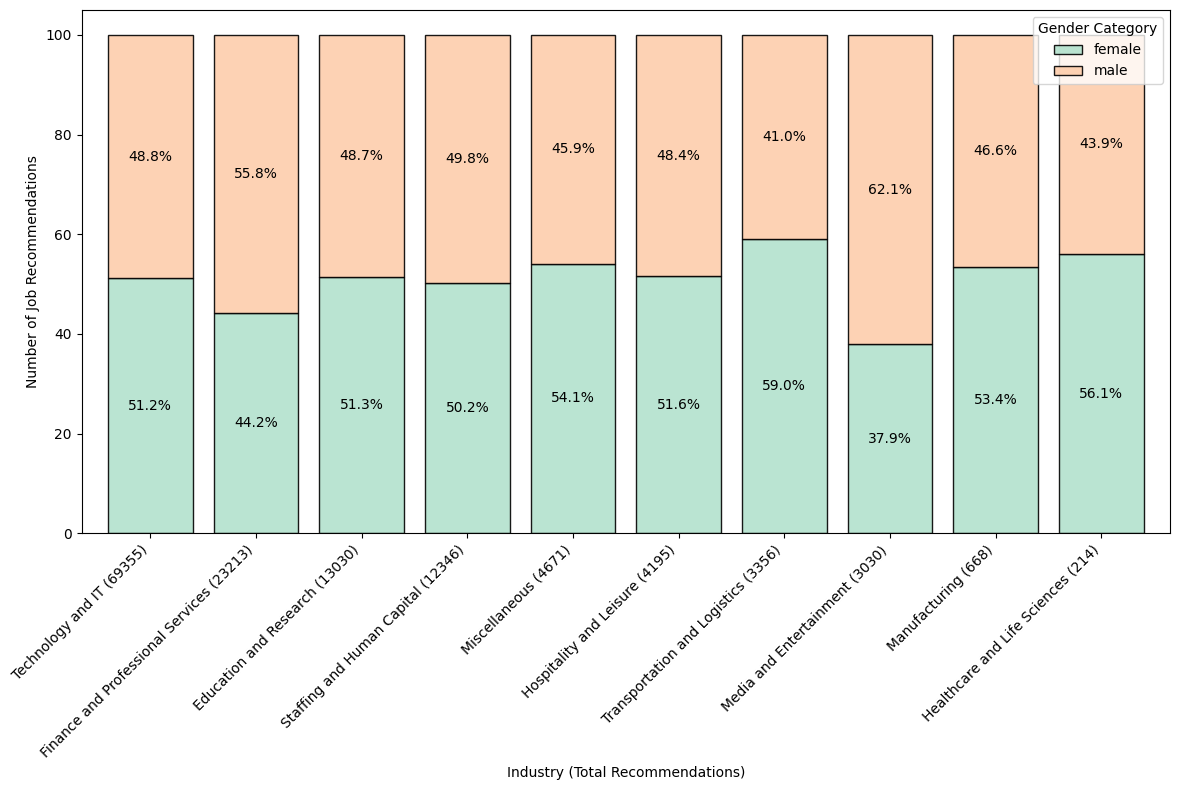

In [48]:
# Plot
fig, ax = plt.subplots(figsize=(12, 8))
colors = plt.cm.Pastel2.colors
bars = industry_gender_percent.plot(kind='bar', stacked=True, color=colors[:len(industry_gender_top.columns)] , ax=ax, width=0.8, alpha=0.9, edgecolor="black")
# colormap="Pastel2",
# Add percentage labels manually
for i, container in enumerate(ax.containers):
    gender = industry_gender_top.columns[i]  # Column (gender)
    for bar, perc in zip(container.patches, industry_gender_percent[gender]):
        if bar.get_height() > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_y() + bar.get_height() / 2,
                f"{perc:.1f}%",
                ha='center',
                va='center',
                fontsize=10,
                color='black'
            )

# Customize plot
# plt.title('Distribution of Applicant Gender per Industry')
plt.xlabel('Industry (Total Recommendations)')
plt.ylabel('Number of Job Recommendations')
plt.legend(title='Gender Category')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('grouped_industry_tf_idf.png')
plt.show()

## Applicant Gender vs Role

In [106]:
# Group and count
role_counts = recommendations_df.groupby(['applicant_gender', 'grouped_role']).size().reset_index(name='count')
role_counts

,applicant_gender,grouped_role,count
0,female,Academic,409
1,female,Architect,406
2,female,Back-End,23809
3,female,Cloud Computing Architect,81
4,female,Consultant,973
5,female,Content Management System,48
6,female,Data Scientist or Machine Learning Specialist,2752
7,female,Data and Analytics,4762
8,female,Database Administrator,738
9,female,Designer,1501


In [107]:
# 🛑 Filter: Keep only roles present in roles_with_disparity
# filtered_roles = role_counts[role_counts['role'].isin(roles_with_disparity)]
filtered_roles = role_counts
# Now get the unique role titles across all genders (after filtering)
roles = filtered_roles['grouped_role'].unique()
genders = filtered_roles['applicant_gender'].unique()

# Build pivot table
pivot_table = filtered_roles.pivot_table(index='grouped_role', columns='applicant_gender', values='count', fill_value=0)

# Calculate percentages for each gender per role
pivot_percentages = pivot_table.div(pivot_table.sum(axis=1), axis=0) * 100

# Ensure role order matches
pivot_table = pivot_table.reindex(roles)
pivot_percentages = pivot_percentages.reindex(roles)

In [108]:
pivot_table

applicant_gender,female,male
grouped_role,,
Academic,409,250
Architect,406,509
Back-End,23809,23615
Cloud Computing Architect,81,75
Consultant,973,982
Content Management System,48,44
Data Scientist or Machine Learning Specialist,2752,2585
Data and Analytics,4762,4044
Database Administrator,738,322


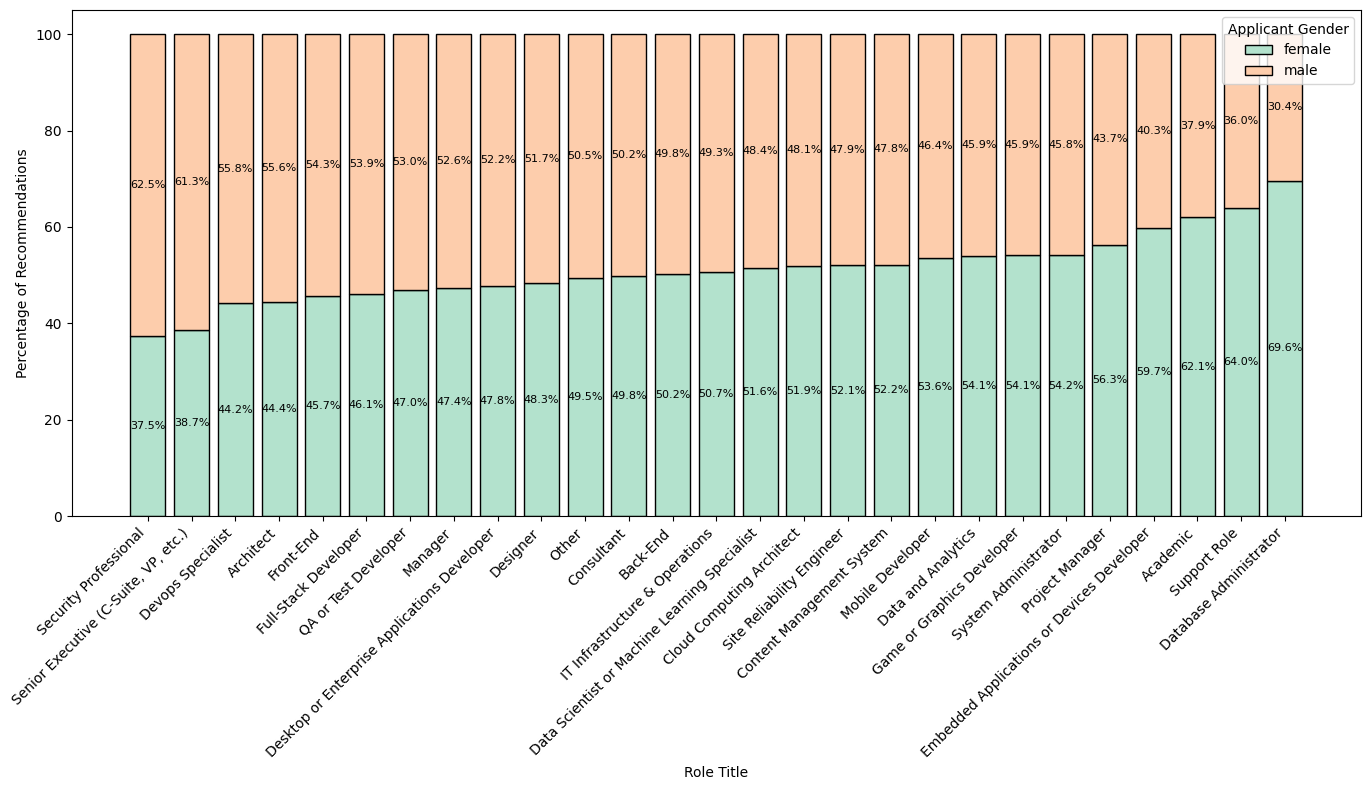

In [109]:
# Sort roles by highest male percentage
sorted_df = pivot_percentages.sort_values(by='male', ascending=False)
roles_sorted = sorted_df.index
x = np.arange(len(roles_sorted))

# Plot setup
fig, ax = plt.subplots(figsize=(14, 8))
colors = plt.cm.Pastel2.colors

# Plot stacked bars
bottom = np.zeros(len(roles_sorted))
for i, gender in enumerate(genders):
    values = sorted_df[gender]
    ax.bar(x, values, bottom=bottom, label=gender, color=colors[i % len(colors)], edgecolor='black')
    
    # Add percentages above bars
    for xi, yi, base in zip(x, values, bottom):
        if yi > 0:
            ax.text(xi, base + yi / 2, f"{yi:.1f}%", ha='center', va='center', fontsize=8)
    
    bottom += values

# Formatting
ax.set_xticks(x)
ax.set_xticklabels(roles_sorted, rotation=45, ha='right')
ax.set_xlabel('Role Title')
ax.set_ylabel('Percentage of Recommendations')
# ax.set_title('Recommended Roles by Applicant Gender (Percentages)')
ax.legend(title='Applicant Gender')
plt.tight_layout()
plt.savefig('roles_word2vec_skipgrams_bigrams')
plt.show()
